In [1]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import numpy as np
import pandas as pd


In [2]:
cell_type_colors = {
    # Neurons
    'glutamatergic neuron':          '#31688e',
    'medium spiny neuron':           '#6a3d9a',
    # Inhibitory interneurons
    'GABAergic interneuron':         '#e31a1c',
    'Vip+ interneuron':              '#fb9a99',
    'Pvalb+ interneuron':            '#fdbf6f',
    'Sst+ interneuron':              '#ff7f00',
    'Lamp5+ interneuron':            '#cab2d6',
    # Glia & support
    'astrocyte':                     '#33a02c',
    'microglial cell':               '#b2df8a',
    'oligodendrocyte':               '#e6ab02',
    'oligodendrocyte precursor cell':'#ffff99',
    'ependymal cell':                '#fccde5',
    # Vascular & barrier
    'endothelial cell':              '#6baed6',
    'epithelial cell':               '#8dd3c7',
    'pericyte':                      '#808080',
    'vascular leptomeningeal cell':  '#b15928',
}


In [3]:
broad_share    = pd.read_csv('annotations/Broad_SHARE_RNA_annotated_metadata.csv')
uci_share      = pd.read_csv('annotations/UCI_SHARE_RNA_annotated_metadata.csv')
parse          = pd.read_csv('annotations/Parse_RNA_annotated_metadata.csv')
stanford       = pd.read_csv('annotations/10x_RNA_annotated_metadata.csv')
merged_harmony = pd.read_csv('annotations/Bridge_RNA_annotated_metadata_harmony.csv')

# Normalise dataset labels in the harmonised object
dataset_map = {
    'Stanford_10x_Multiome': '10x_Multiome',
    'UCI_Parse_Split-seq':   'Parse_Split-seq',
    'Broad_SHARE-seq':       'SHARE-seq_B',
    'UCI_SHARE-seq':         'SHARE-seq_U',
}
merged_harmony['dataset'] = (
    merged_harmony['Institution'].astype(str) + '_' +
    merged_harmony['Preferred_Assay_Title'].astype(str)
).str.replace(' ', '_').map(dataset_map)


/tmp/ipykernel_3981517/738606008.py:4: DtypeWarning: Columns (22,25,27,28,31) have mixed types. Specify dtype option on import or set low_memory=False.
  stanford       = pd.read_csv('annotations/10x_RNA_annotated_metadata.csv')
/tmp/ipykernel_3981517/738606008.py:5: DtypeWarning: Columns (11,12,15,22,25,27,28,31,55,56,57,58,59,60,61) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_harmony = pd.read_csv('annotations/Bridge_RNA_annotated_metadata_harmony.csv')


In [4]:
def stacked_barplot_proportions(
    adata,
    cluster_key,
    var_key,
    fsize=(12, 6),
    annotations=True,
    sort_by_size=True,
    reverse_order=True,
    custom_order=None,
    var_order=None,
    custom_colors=None,
    remove_y_labels=False,
    save_path=None,
    annotation_x=0.92,
    xlim=(0, 1.15),
    strict_colors=False,
    show_legend=True,
    legend_bbox=(1.2, 1.0),
    legend_loc='upper left',
):
    """Horizontal stacked bar chart of category proportions within clusters."""
    df = adata.obs if hasattr(adata, 'obs') else adata
    if not isinstance(df, pd.DataFrame):
        raise TypeError('`adata` must be a DataFrame or AnnData with .obs.')

    for k in (cluster_key, var_key):
        if k not in df.columns:
            raise KeyError(f"Column '{k}' not found in input data.")

    df = df.copy()
    df[cluster_key] = df[cluster_key].astype(str).str.strip()
    df[var_key]     = df[var_key].astype(str).str.strip()

    counts      = df.groupby(cluster_key).size().rename('n').to_frame()
    grouped     = df.groupby([cluster_key, var_key]).size().unstack(fill_value=0)
    proportions = grouped.div(grouped.sum(axis=1), axis=0)

    if var_order is not None:
        var_order = [str(v).strip() for v in var_order]
        proportions = proportions.reindex(
            columns=[v for v in var_order if v in proportions.columns], fill_value=0
        )

    if custom_order is not None:
        custom_order = [str(c).strip() for c in custom_order]
        idx = [c for c in custom_order if c in proportions.index]
    elif sort_by_size:
        idx = counts['n'].sort_values(ascending=False).index
    else:
        idx = proportions.index

    proportions = proportions.reindex(idx)
    counts      = counts.reindex(idx)

    if reverse_order:
        proportions = proportions.iloc[::-1]
        counts      = counts.iloc[::-1]

    if proportions.shape[1] == 0:
        raise ValueError(f"No categories to plot for var_key='{var_key}'.")

    cols = list(proportions.columns)

    if custom_colors is None:
        colors = sns.color_palette('husl', n_colors=len(cols))
    elif isinstance(custom_colors, dict):
        cmap    = {str(k).strip(): v for k, v in custom_colors.items()}
        missing = [c for c in cols if c not in cmap]
        if missing and strict_colors:
            raise ValueError(f'custom_colors missing entries for: {missing}')
        if missing:
            auto = sns.color_palette('husl', n_colors=len(missing))
            cmap.update(dict(zip(missing, auto)))
        colors = [cmap[c] for c in cols]
    else:
        if len(custom_colors) != len(cols):
            raise ValueError(
                f'custom_colors length {len(custom_colors)} != {len(cols)} categories.'
            )
        colors = list(custom_colors)

    ax = proportions.plot(
        kind='barh', color=colors, stacked=True,
        figsize=fsize, width=0.8, edgecolor='none',
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    if annotations:
        for i, n in enumerate(counts['n'].reindex(proportions.index)):
            ax.text(annotation_x, i, str(n), fontsize=15, va='center',
                    transform=ax.get_yaxis_transform())

    ax.set_xlim(*xlim)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xlabel('Proportion', fontsize=18)
    ax.set_title(var_key, fontsize=20)
    ax.set_ylabel(cluster_key, fontsize=18)

    leg = ax.get_legend()
    if leg is not None:
        if show_legend:
            leg.set_title(var_key)
            leg.set_bbox_to_anchor(legend_bbox)
            leg.set_loc(legend_loc)
            for t in leg.get_texts():
                t.set_fontsize(12)
            if leg.get_title() is not None:
                leg.get_title().set_fontsize(12)
        else:
            leg.remove()

    if remove_y_labels:
        ax.set_ylabel('')
        ax.tick_params(axis='y', left=False)
        ax.set_yticklabels([])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [5]:
def resolve_celltypes(series_iter, palette=cell_type_colors):
    """Return (celltype_order, colors_complete) from one or more pd.Series of cell types."""
    all_ct = set()
    for s in series_iter:
        all_ct |= set(s.astype(str).str.strip().unique())

    ordered = [ct for ct in palette if ct in all_ct]
    extras  = sorted(all_ct - set(ordered))
    ordered += extras

    colors = dict(palette)
    if extras:
        auto = sns.color_palette('husl', n_colors=len(extras))
        colors.update(dict(zip(extras, auto)))

    return ordered, colors


## Cell-type composition — individual datasets

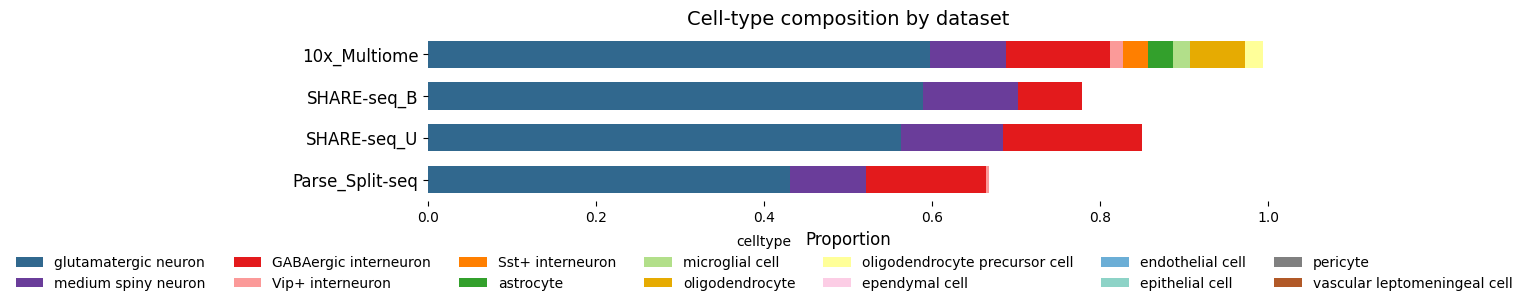

In [6]:
datasets = {
    '10x_Multiome':  stanford,
    'SHARE-seq_B':   broad_share,
    'SHARE-seq_U':   uci_share,
    'Parse_Split-seq': parse,
}
dataset_order = list(datasets.keys())

celltype_order, colors_complete = resolve_celltypes(
    [df['celltype'] for df in datasets.values()]
)

# Proportion of each cell type within each dataset
prop_df = pd.DataFrame({
    name: df['celltype'].astype(str).str.strip().value_counts(normalize=True)
    for name, df in datasets.items()
}).T.reindex(columns=celltype_order, fill_value=0).reindex(dataset_order)

fig, ax = plt.subplots(figsize=(10.5, 3.0))
left = np.zeros(len(prop_df))
y    = np.arange(len(prop_df))

for ct in celltype_order:
    vals = prop_df[ct].to_numpy()
    if vals.sum() == 0:
        continue
    ax.barh(y, vals, left=left, color=colors_complete[ct],
            edgecolor='none', height=0.65)
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(prop_df.index, fontsize=12)
ax.set_xlim(0, 1)
ax.set_xlabel('Proportion', fontsize=12)
ax.set_title('Cell-type composition by dataset', fontsize=14)
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

handles = [
    Patch(facecolor=colors_complete[ct], edgecolor='none', label=ct)
    for ct in celltype_order if prop_df[ct].sum() > 0
]
fig.legend(handles=handles, title='celltype', loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=int(np.ceil(len(handles) / 2)), frameon=False)

fig.subplots_adjust(bottom=0.32, left=0.18, right=0.98)
plt.show()


## Cell-type composition — harmonised dataset

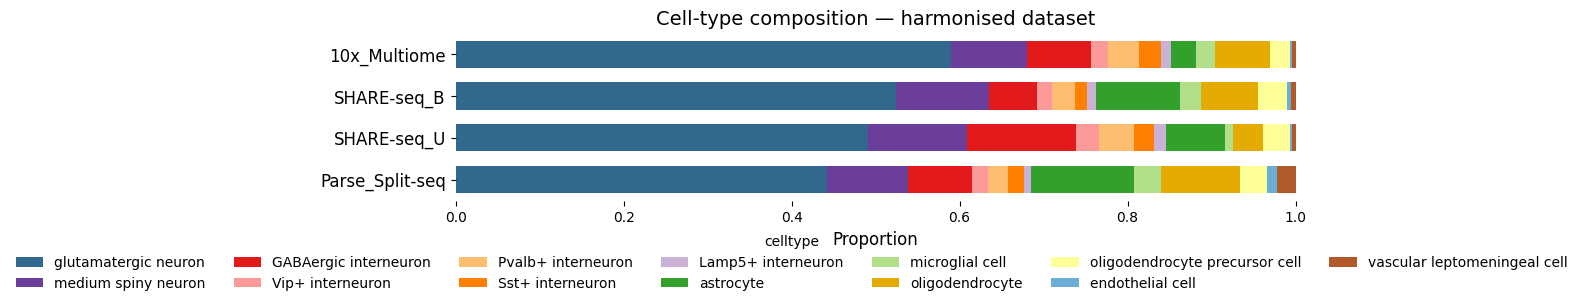

In [7]:
df = merged_harmony[['dataset', 'celltype']].copy()
df['celltype'] = df['celltype'].astype(str).str.strip()
df['dataset']  = df['dataset'].astype(str).str.strip()

celltype_order, colors_complete = resolve_celltypes([df['celltype']])

dataset_order = ['10x_Multiome', 'SHARE-seq_B', 'SHARE-seq_U', 'Parse_Split-seq']

prop_df = (
    df.groupby(['dataset', 'celltype'])
      .size()
      .reset_index(name='n')
      .assign(proportion=lambda x: x['n'] / x.groupby('dataset')['n'].transform('sum'))
      .pivot(index='dataset', columns='celltype', values='proportion')
      .reindex(index=dataset_order, columns=celltype_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(10.5, 3.0))
left = np.zeros(len(prop_df))
y    = np.arange(len(prop_df))

for ct in celltype_order:
    vals = prop_df[ct].values
    if vals.sum() == 0:
        continue
    ax.barh(y, vals, left=left, color=colors_complete[ct],
            edgecolor='none', height=0.65)
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(prop_df.index, fontsize=12)
ax.set_xlim(0, 1)
ax.set_xlabel('Proportion', fontsize=12)
ax.set_title('Cell-type composition — harmonised dataset', fontsize=14)
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

handles = [
    Patch(facecolor=colors_complete[ct], edgecolor='none', label=ct)
    for ct in celltype_order if prop_df[ct].sum() > 0
]
fig.legend(handles=handles, title='celltype', loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=int(np.ceil(len(handles) / 2)), frameon=False)

fig.subplots_adjust(bottom=0.32, left=0.18, right=0.98)
plt.show()


## Cell-type proportions — grouped bar chart

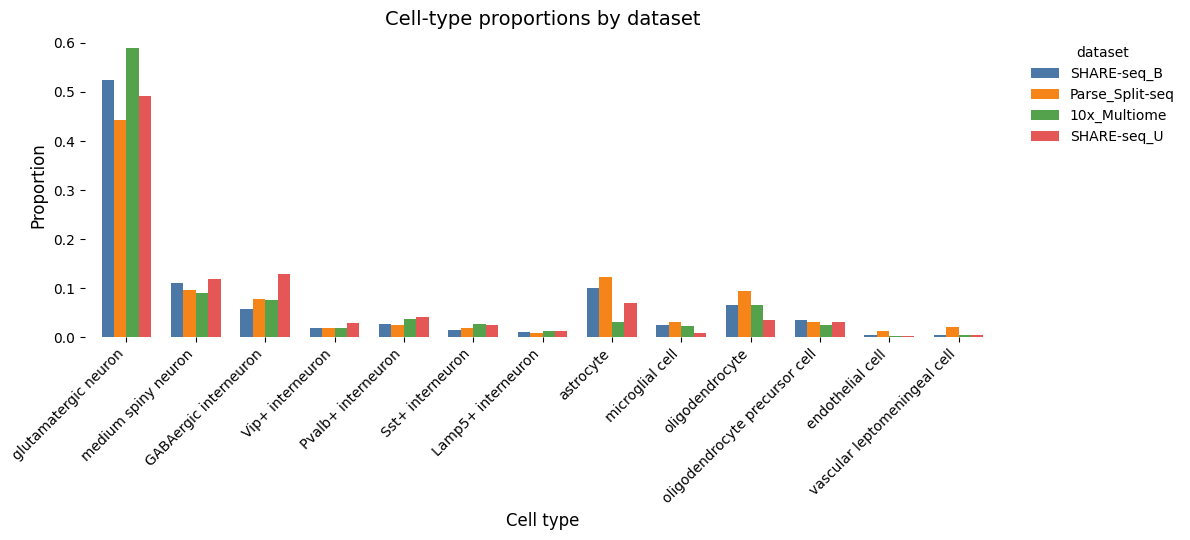

In [8]:
dataset_colors = {
    'SHARE-seq_B':   '#4C78A8',
    'Parse_Split-seq': '#F58518',
    '10x_Multiome':  '#54A24B',
    'SHARE-seq_U':   '#E45756',
}
dataset_order = list(dataset_colors.keys())

P = (
    df.groupby(['dataset', 'celltype'])
      .size()
      .reset_index(name='n')
      .assign(proportion=lambda x: x['n'] / x.groupby('dataset')['n'].transform('sum'))
      .pivot(index='celltype', columns='dataset', values='proportion')
      .reindex(index=celltype_order, columns=dataset_order, fill_value=0)
)

n_ct = len(celltype_order)
n_ds = len(dataset_order)
x    = np.arange(n_ct)
bar_w = 0.18

fig, ax = plt.subplots(figsize=(max(12, 0.55 * n_ct), 5.5))

for j, d in enumerate(dataset_order):
    offset = (j - (n_ds - 1) / 2) * bar_w
    ax.bar(x + offset, P[d].values, width=bar_w,
           color=dataset_colors[d], edgecolor='none', label=d)

ax.set_xlim(-0.6, n_ct - 0.4)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_xlabel('Cell type', fontsize=12)
ax.set_title('Cell-type proportions by dataset', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(celltype_order, rotation=45, ha='right', fontsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(title='dataset', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


## Difference in cell-type proportions vs baseline

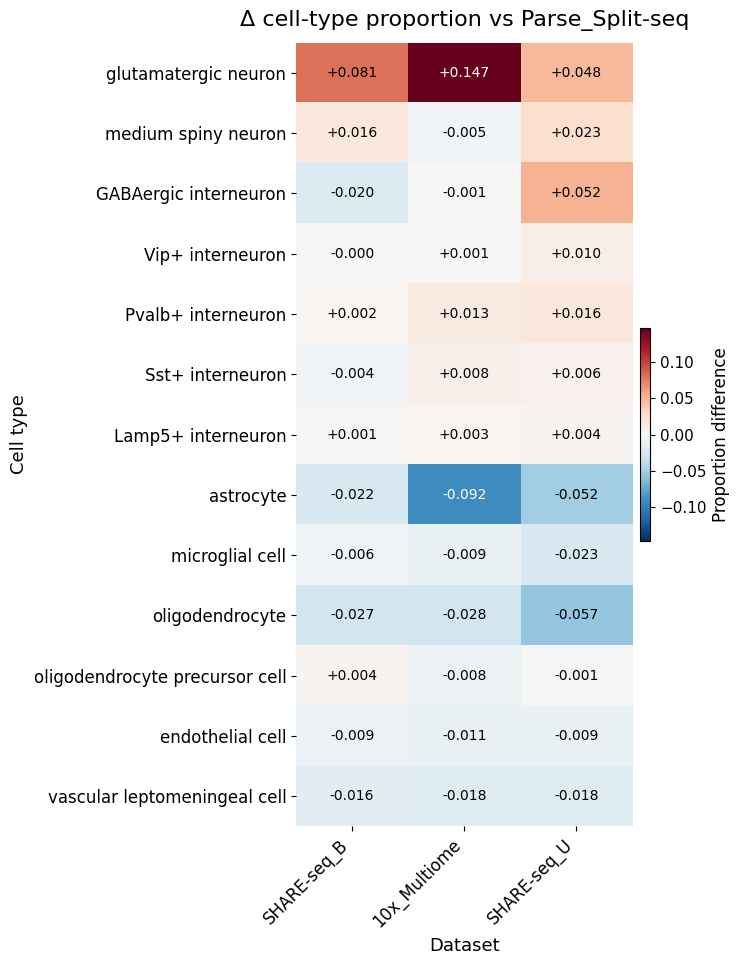

In [9]:
baseline         = 'Parse_Split-seq'
compare_datasets = [d for d in dataset_order if d != baseline]

diff = P[compare_datasets].sub(P[baseline], axis=0)

vals   = diff.values
absmax = max(np.nanmax(np.abs(vals)), 1e-6)

fig, ax = plt.subplots(figsize=(7.5, max(6, 0.75 * len(diff.index))))

im = ax.imshow(vals, aspect='auto', cmap='RdBu_r', vmin=-absmax, vmax=absmax)

ax.set_xticks(np.arange(len(compare_datasets)))
ax.set_xticklabels(compare_datasets, rotation=45, ha='right', fontsize=12)
ax.set_yticks(np.arange(len(diff.index)))
ax.set_yticklabels(diff.index, fontsize=12)
ax.set_title(f'Δ cell-type proportion vs {baseline}', fontsize=16, pad=12)
ax.set_xlabel('Dataset', fontsize=13)
ax.set_ylabel('Cell type', fontsize=13)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v = vals[i, j]
        ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=10,
                color='white' if abs(v) >= absmax * 0.6 else 'black')

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Proportion difference', fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()


## Original → harmonised annotation mapping (Sankey diagrams)

/tmp/ipykernel_3981517/3981443233.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', n) if n <= 20 else plt.cm.hsv
/tmp/ipykernel_3981517/3981443233.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x1400 with 0 Axes>

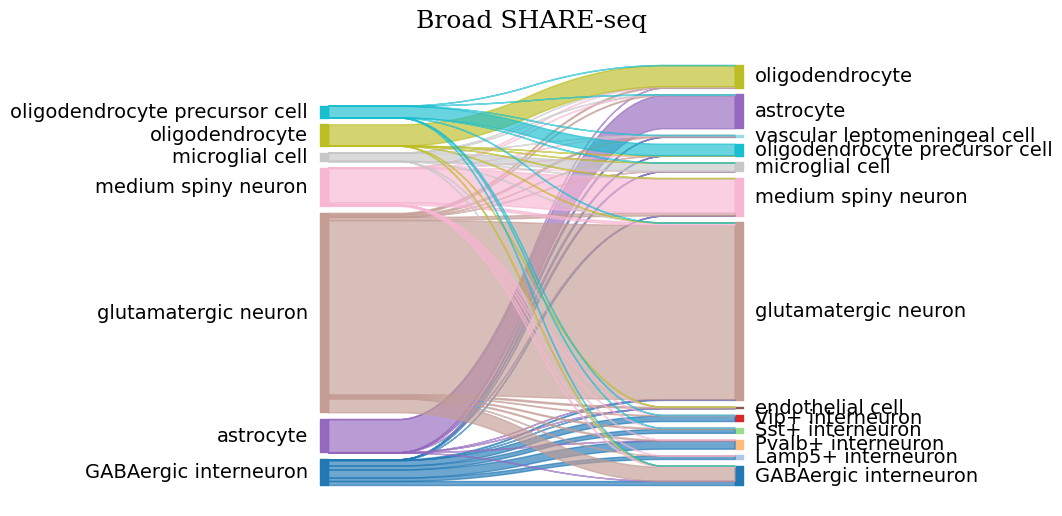

/tmp/ipykernel_3981517/3981443233.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', n) if n <= 20 else plt.cm.hsv
/tmp/ipykernel_3981517/3981443233.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x1400 with 0 Axes>

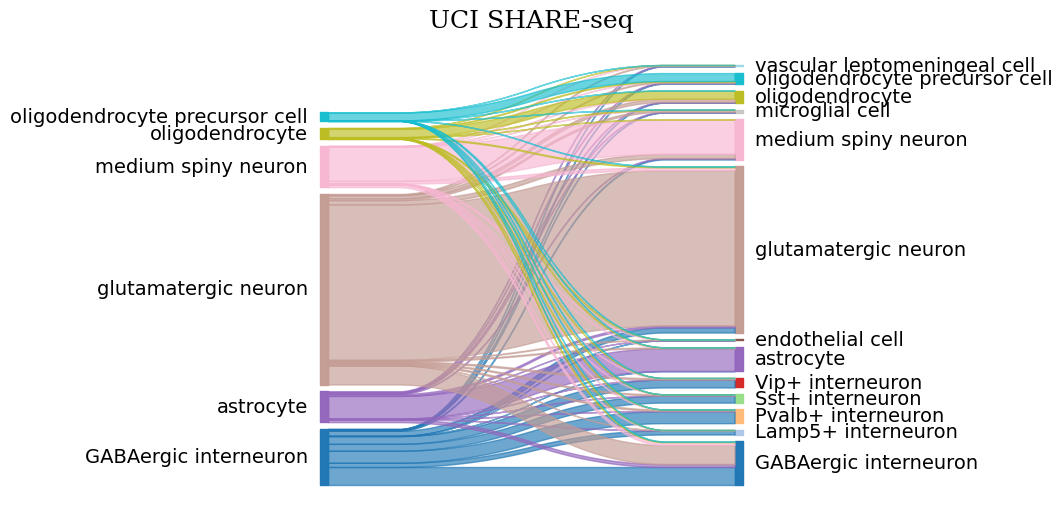

/tmp/ipykernel_3981517/3981443233.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', n) if n <= 20 else plt.cm.hsv
/tmp/ipykernel_3981517/3981443233.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x1400 with 0 Axes>

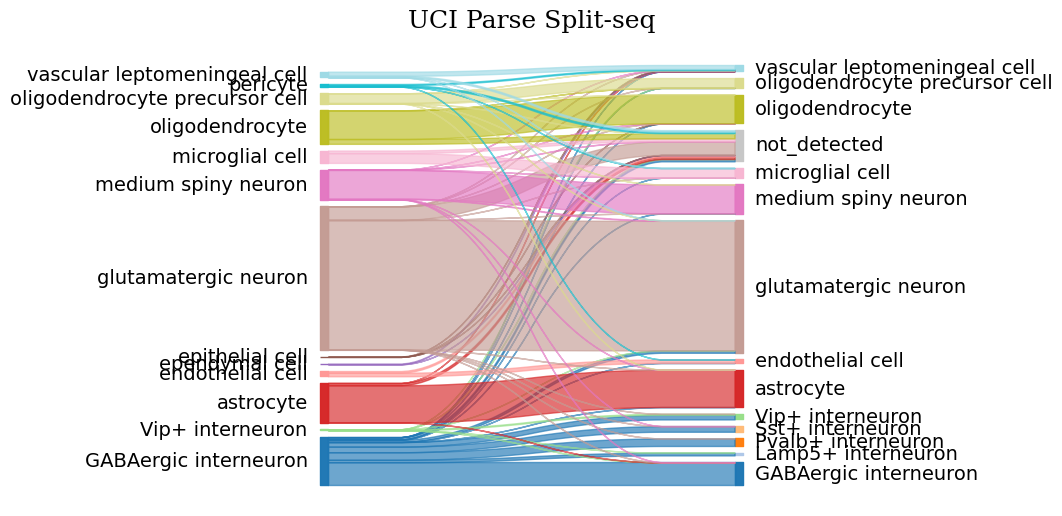

/tmp/ipykernel_3981517/3981443233.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', n) if n <= 20 else plt.cm.hsv
/tmp/ipykernel_3981517/3981443233.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x1400 with 0 Axes>

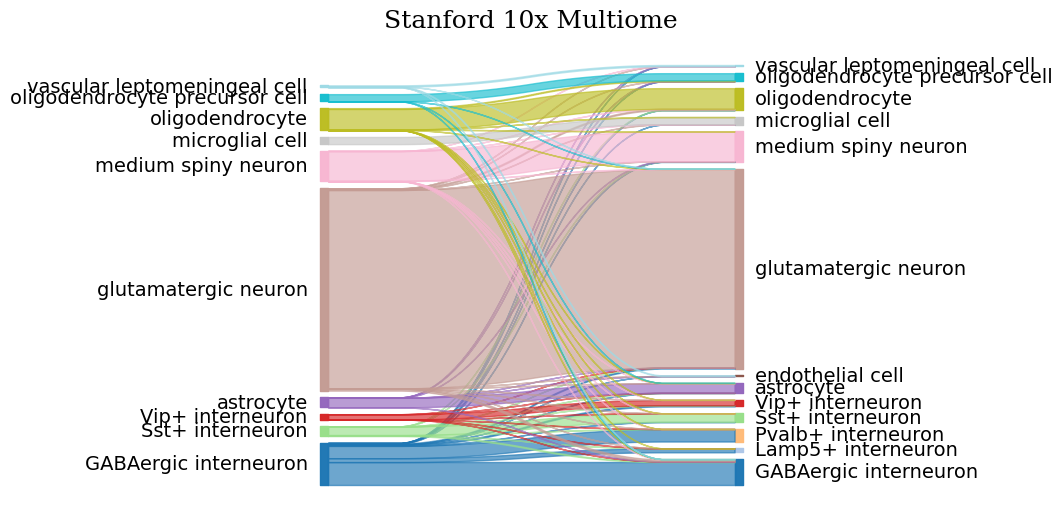

In [10]:
from pySankey.sankey import sankey as pysankey

mpl.rcParams['font.family'] = 'DejaVu Sans'

# Map each barcode to its harmonised cell type
harm_lookup = (
    merged_harmony[['barcode', 'celltype']]
    .rename(columns={'celltype': 'harmonized_celltype'})
    .drop_duplicates('barcode')
)

def make_celltype_df(meta):
    """Join per-dataset annotations with harmonised labels."""
    return (
        meta[['barcode', 'celltype']]
        .rename(columns={'celltype': 'original_celltype'})
        .merge(harm_lookup, on='barcode', how='left')
    )

broad_share_df = make_celltype_df(broad_share)
uci_share_df   = make_celltype_df(uci_share)
parse_df       = make_celltype_df(parse)
stanford_df    = make_celltype_df(stanford)


def plot_annotation_sankey(df, title,
                            left_col='original_celltype',
                            right_col='harmonized_celltype',
                            figsize=(12, 14), fontsize=14, aspect=20):
    """Sankey diagram comparing two annotation columns."""
    plot_df = df[[left_col, right_col]].fillna('not_detected').copy()

    all_labels = pd.Index(
        sorted(set(plot_df[left_col]).union(set(plot_df[right_col])))
    )
    for col in (left_col, right_col):
        plot_df[col] = pd.Categorical(plot_df[col], categories=all_labels, ordered=True)
    plot_df = plot_df.sort_values([left_col, right_col])

    n = len(all_labels)
    cmap   = plt.cm.get_cmap('tab20', n) if n <= 20 else plt.cm.hsv
    colors = {
        lbl: mpl.colors.to_hex(cmap(i / n if n > 20 else i))
        for i, lbl in enumerate(all_labels)
    }

    plt.figure(figsize=figsize)
    pysankey(left=plot_df[left_col], right=plot_df[right_col],
             aspect=aspect, fontsize=fontsize, colorDict=colors)
    plt.title(title, fontsize=18, pad=12)
    for text in plt.gca().texts:
        text.set_fontfamily('DejaVu Sans')
    plt.tight_layout()
    plt.show()


plot_annotation_sankey(broad_share_df, 'Broad SHARE-seq')
plot_annotation_sankey(uci_share_df,   'UCI SHARE-seq')
plot_annotation_sankey(parse_df,       'UCI Parse Split-seq')
plot_annotation_sankey(stanford_df,    'Stanford 10x Multiome')


## QC metrics

In [11]:
adata = sc.read('../results/Bridge_RNA_adata_annotated_harmony.h5ad')

adata.obs['dataset'] = (
    adata.obs['Institution'].astype(str) + '_' +
    adata.obs['Preferred_Assay_Title'].astype(str)
).str.replace(' ', '_').map(dataset_map)

adata.var.index = adata.var.index.astype(str)
adata.var_names_make_unique()


/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [12]:
biotype_df  = pd.read_csv(
    '/dfs9/seyedam-lab/weberrl/crsp_weberrl/igvf_genocode_36_biotypes.txt',
    sep='\t', header=None
)
biotype_map = dict(zip(biotype_df[0], biotype_df[1]))
adata.var['biotype'] = adata.var['gene_name_unique'].map(biotype_map).astype(str)

biotypes = ['lncRNA', 'protein_coding', 'processed_pseudogene', 'miRNA', 'snoRNA', 'snRNA']
for bt in biotypes:
    adata.var[bt] = (adata.var['biotype'] == bt).values

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=biotypes,
    layer='cellbender_counts',
    percent_top=None,
    log1p=False,
    inplace=True,
)

# Consistent dataset label order
adata.obs['dataset'] = pd.Categorical(
    adata.obs['dataset'],
    categories=['10x_Multiome', 'Parse_Split-seq', 'SHARE-seq_B', 'SHARE-seq_U'],
    ordered=True,
)


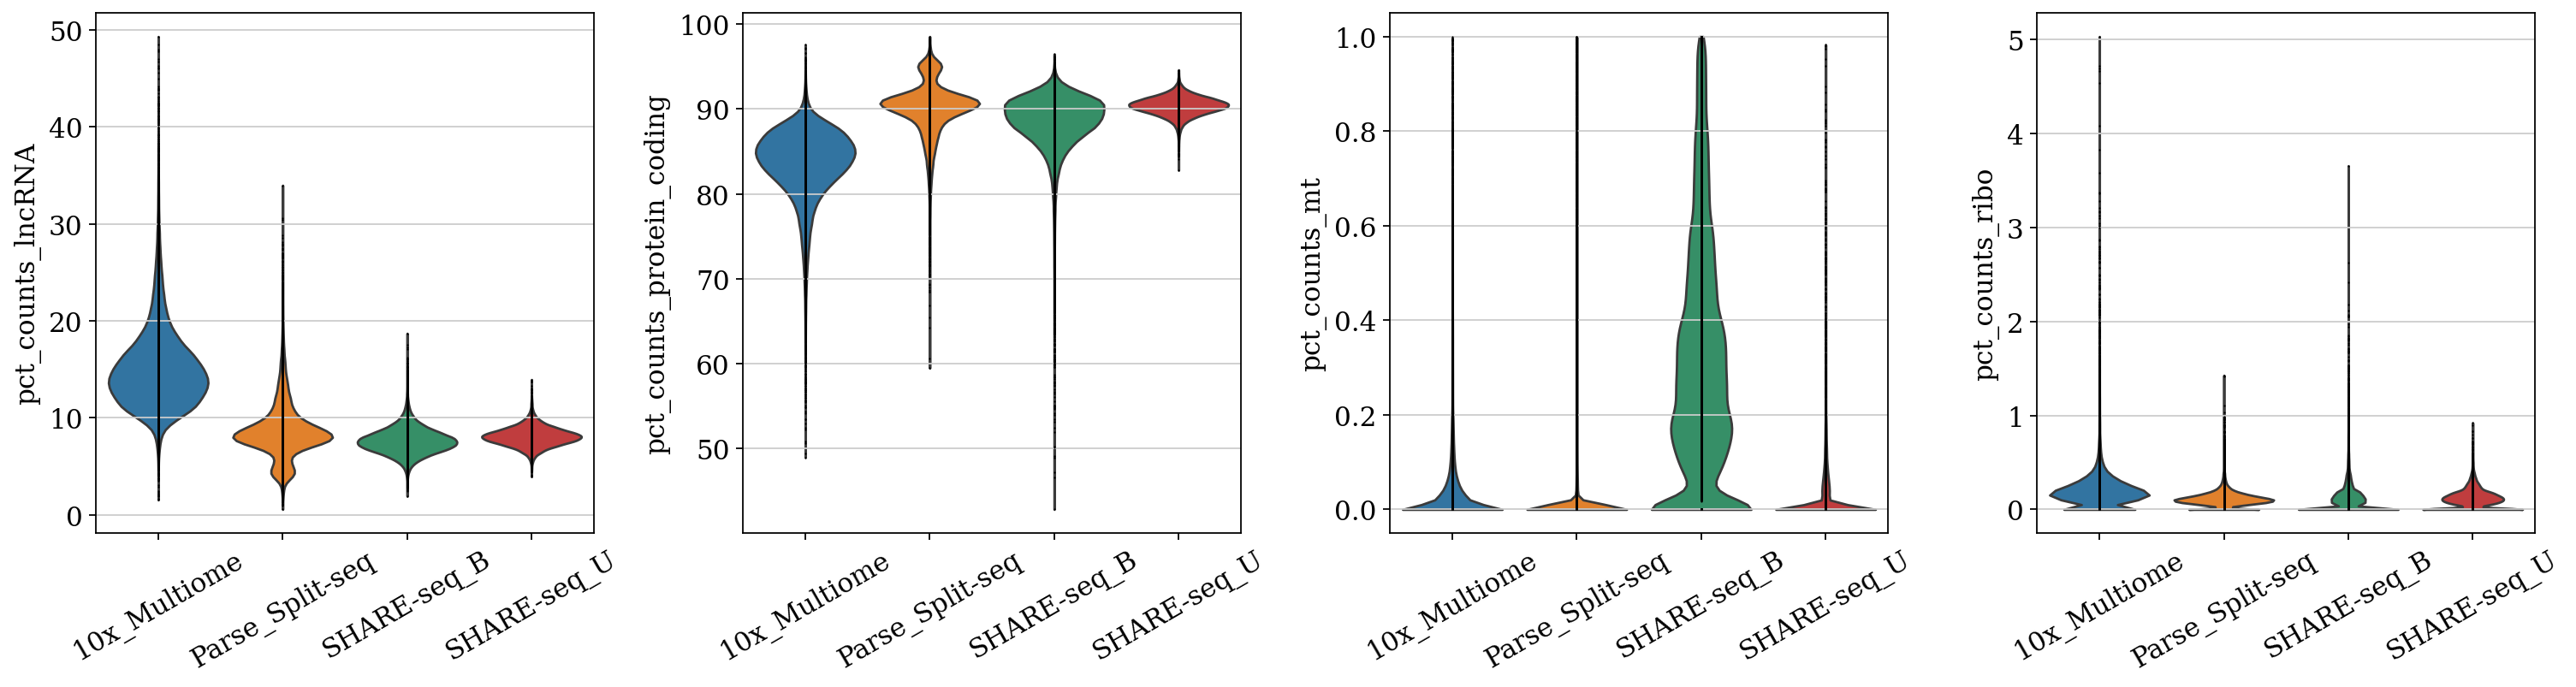

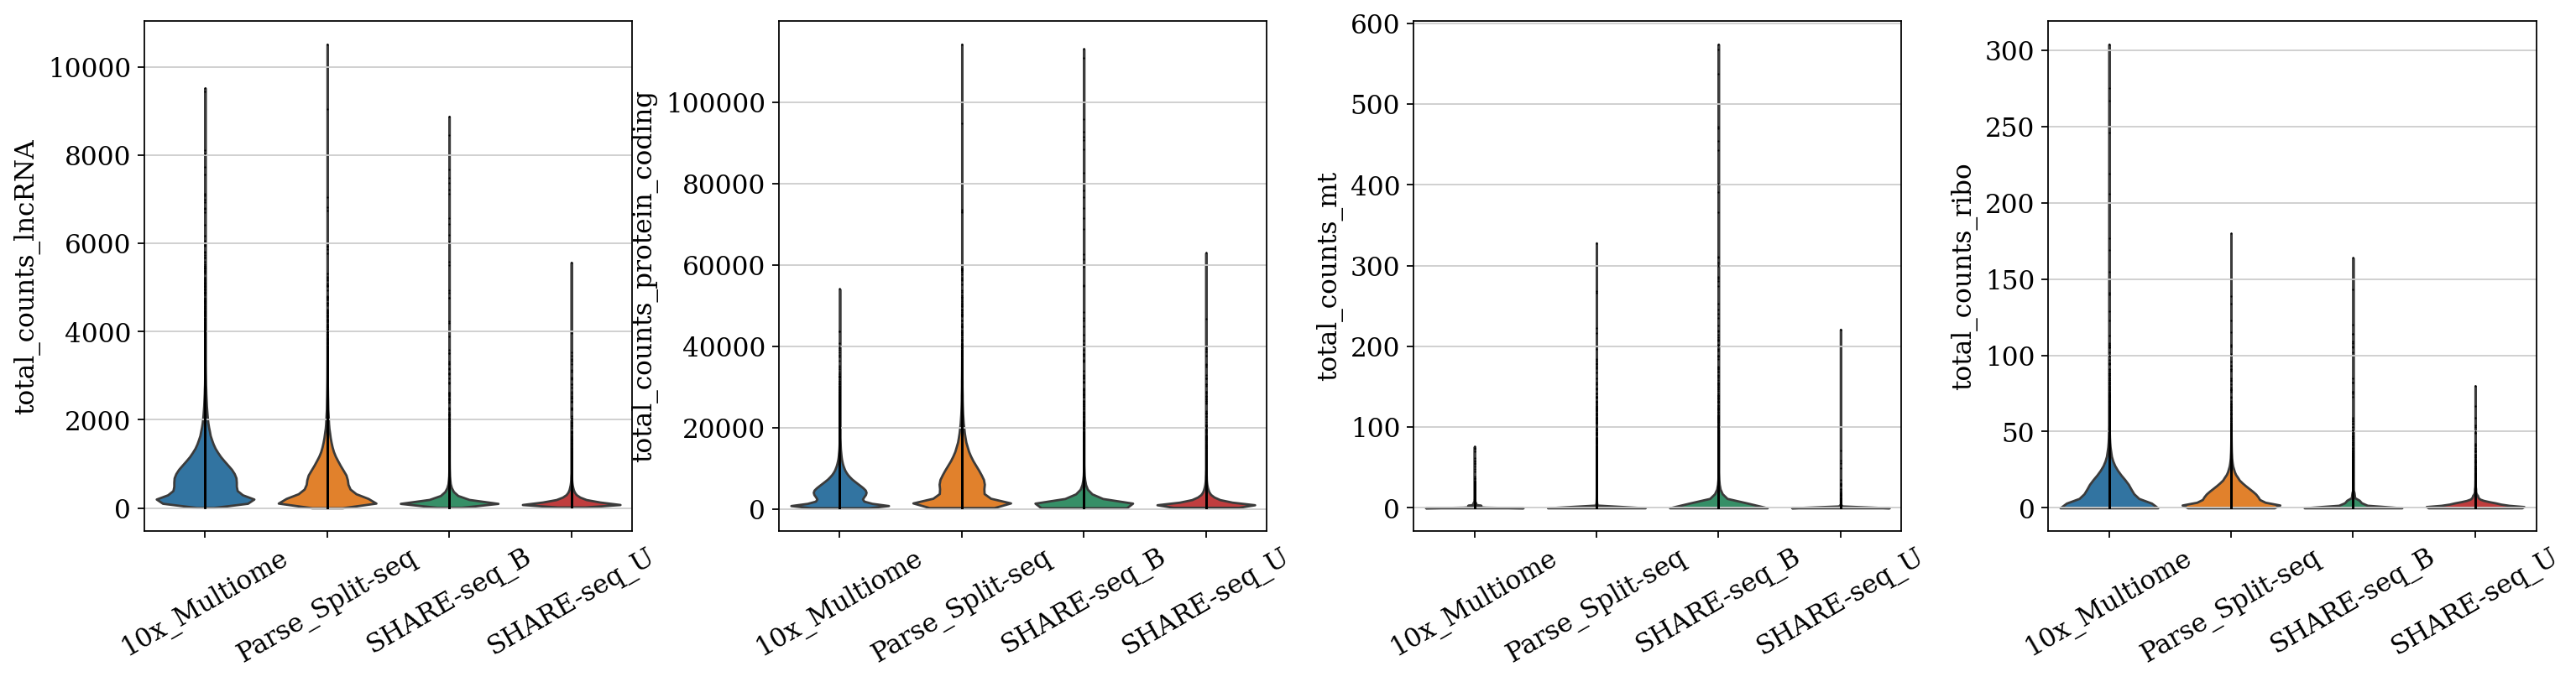

In [13]:
qc_pct_vars   = ['pct_counts_lncRNA', 'pct_counts_protein_coding',
                  'pct_counts_mt', 'pct_counts_ribo']
qc_total_vars = ['total_counts_lncRNA', 'total_counts_protein_coding',
                  'total_counts_mt', 'total_counts_ribo']

violin_kwargs = dict(groupby='dataset', jitter=0.0, multi_panel=True, rotation=30)

sc.set_figure_params(figsize=(4.75, 5))
sc.pl.violin(adata, qc_pct_vars,   **violin_kwargs)
sc.pl.violin(adata, qc_total_vars, **violin_kwargs)
